In [15]:
import wandb
import pandas as pd
import numpy as np
import json
import seaborn as sns

from matplotlib import pyplot as plt
%matplotlib inline

In [16]:
api = wandb.Api()

In [17]:
runs = api.runs(path="harvardml/opt-olmo")

In [18]:
optimizers = ['sgdw', 'adamw', 'novagradw_ours', 'adafactorw', 'lionw', 'signsgd',  'sophiag',] 
display_names = ['SGD', 'Adam',   'NovoGrad', 'Adafactor', 'Lion', 'Signum', 'Sophia G',]
colors = sns.color_palette('Set2', n_colors=len(optimizers))

color_map = dict(zip(optimizers, colors))
name_map = dict(zip(optimizers, display_names))

In [19]:
df = pd.DataFrame()

steps = [100, 300, 500, 900, 1700, 2900, 4900, 8500, 14600, 25000]
step = 100000
groups = ["optimizers-150-long-2", "optimizers-llama-lite-150-long-1"]
plot_key = "learning_rate"
display_key = "Learning Rate"

for run in runs:
    if run.group in groups:
        history = run.history(samples=50000, 
                        keys=[
                            "eval/c4_val/CrossEntropyLoss", 
                            "train/CrossEntropyLoss", 
                            "optim/total_grad_norm",
                            ])
    
        run_dict = {}
        run_dict["id"] = run.id
        run_dict["name"] = run.name 
        run_dict["group"] = run.group
        run_dict["optimizer"] = run.config["optimizer"]["name"]
        run_dict[plot_key] = run.config["optimizer"][plot_key]

        if run.group == "optimizers-1" and run_dict["optimizer"] == "sgdw":
            continue
        
        if "eval/c4_val/CrossEntropyLoss" in history:
            if step not in list(history["_step"]):
                run_dict["val_loss"] = 10.0
            else:
                run_dict["val_loss"] = list(history[history["_step"] == step]["eval/c4_val/CrossEntropyLoss"])[0]
                run_dict["step"] = step
        else:
            run_dict["val_loss"] = np.nan
            run_dict["step"] = np.nan
        if run_dict["optimizer"] == "novagradw" and run.config["optimizer"]["att_correction"]:
            run_dict["optimizer"] = "novagradw_ours"
        if (run_dict["optimizer"] == "adafactorw" and 
            "neuron_only" in run.config["optimizer"] and
            run.config["optimizer"]["neuron_only"]
        ):
            run_dict["optimizer"] = "adafactorw_oneside"
        run_df = pd.DataFrame(run_dict, index=[0])
        df = pd.concat([df, run_df])

In [20]:
df

,id,name,group,optimizer,learning_rate,val_loss,step
0,amn2hznl,olmo_33448211_19,optimizers-150-long-2,lionw,0.000010,3.167446,100000.0
0,lcpoi8eo,olmo_33364219_47,optimizers-150-long-2,novagradw_ours,0.000316,2.976128,100000.0
0,ksbp3cue,olmo_33364219_45,optimizers-150-long-2,adafactorw,1.000000,10.000000,NaN
0,bwgs6xnc,olmo_33364219_44,optimizers-150-long-2,adafactorw,0.316000,10.000000,NaN
0,08u40j71,olmo_33364219_46,optimizers-150-long-2,novagradw_ours,0.000100,3.091604,100000.0
...,...,...,...,...,...,...,...
0,r78r08l6,olmo_32987100_4,optimizers-llama-lite-150-long-1,adamw,0.003160,10.000000,NaN
0,9qh3ymkk,olmo_32987100_3,optimizers-llama-lite-150-long-1,adamw,0.001000,10.000000,NaN
0,4ep9398z,olmo_32987100_5,optimizers-llama-lite-150-long-1,adamw,0.010000,10.000000,NaN
0,2gksadhj,olmo_32987100_11,optimizers-llama-lite-150-long-1,sgdw,0.003160,10.000000,NaN


In [21]:
df["optimizer"].unique()

array(['lionw', 'novagradw_ours', 'adafactorw', 'signsgd', 'sgdw',
       'adamw'], dtype=object)

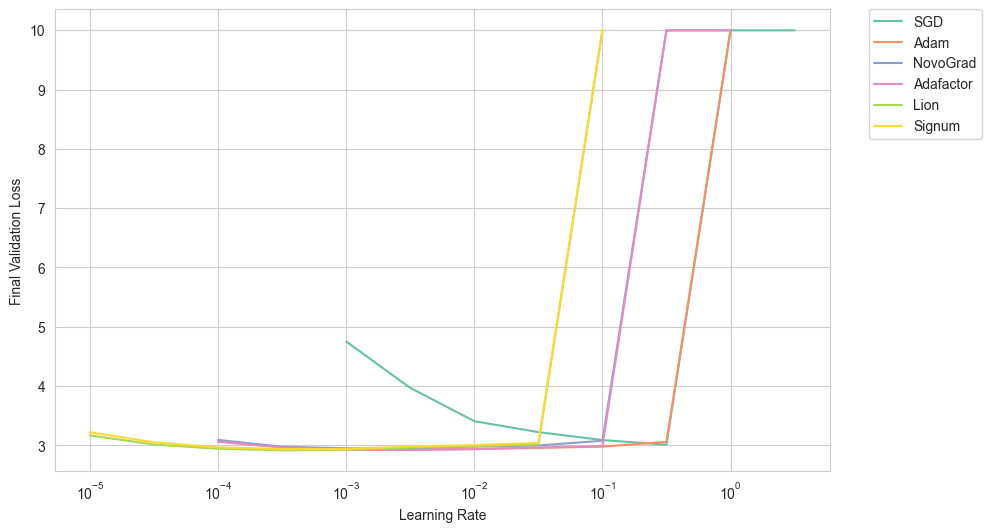

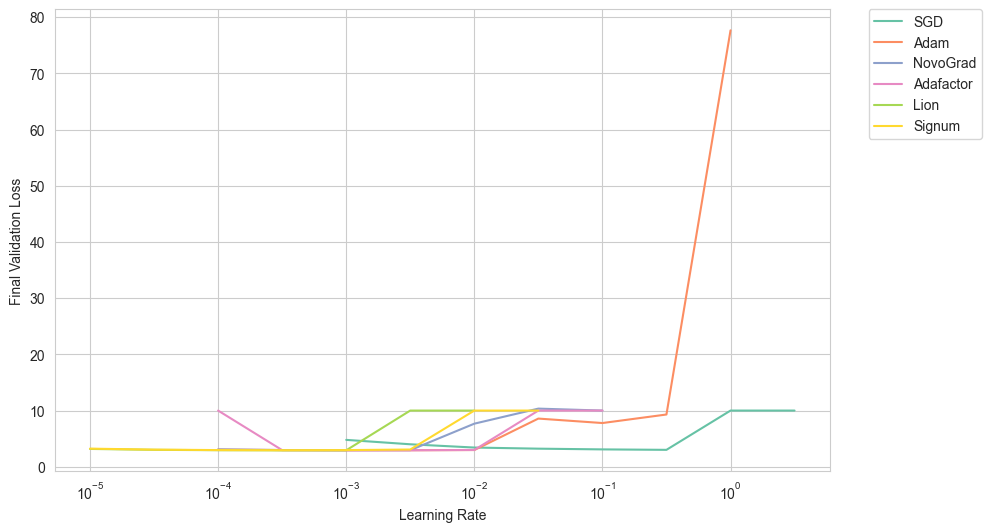

In [22]:
group_lrs = {}
for i, group in enumerate(groups):
    group_df = df[df["group"] == group]

    sns.set_style("whitegrid")
    plt.figure(figsize=(10, 6))  # Larger figure size


    best_lrs = {}
    for optimizer in optimizers:
        if optimizer in group_df["optimizer"].unique():
            optimizer_df = group_df[group_df["optimizer"] == optimizer]
            optimizer_df = optimizer_df.sort_values(by=plot_key)
            optimizer_df = optimizer_df.groupby(plot_key).min().reset_index()
            plt.plot(optimizer_df[plot_key], optimizer_df["val_loss"], label=name_map[optimizer], color=color_map[optimizer])
            
            best_lr = optimizer_df[plot_key][optimizer_df["val_loss"].idxmin()]
            best_lrs[optimizer] = best_lr

    group_lrs[group] = best_lrs

    plt.xscale("log")
    #plt.yscale("log")
    #plt.ylim(3, 4)
    plt.legend()
    plt.xlabel(display_key)
    plt.ylabel("Final Validation Loss")
    plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
    plt.show()

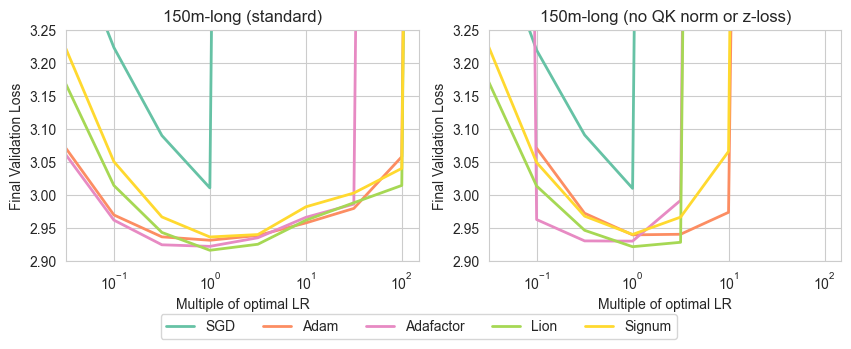

In [23]:
sns.set_style("whitegrid")
fig, axs = plt.subplots(1, 2, figsize=(10, 3))  # Larger figure size

for i, group in enumerate(groups):

    ax = axs[i]
    group_df = df[df["group"] == group]
    best_lrs = group_lrs[group]

    adam_lr = best_lrs["adamw"]
    multipliers = {k: adam_lr / v for k,v in best_lrs.items()}

    for optimizer in optimizers:
        if optimizer in ["sophiag", "novagradw_ours"]:
            continue
        if optimizer in group_df["optimizer"].unique():
            optimizer_df = group_df[group_df["optimizer"] == optimizer]
            optimizer_df = optimizer_df.sort_values(by="learning_rate")
            # take minimal value for each learning rate
            optimizer_df = optimizer_df.groupby("learning_rate").min().reset_index()
            ax.plot(
                multipliers[optimizer] * optimizer_df["learning_rate"] / adam_lr, 
                optimizer_df["val_loss"], 
                label=name_map[optimizer],
                linewidth=2,
                color=color_map[optimizer],
                #linestyle='--' if optimizer in ['adamw', 'sgdw'] else '-'
            )

    ax.set_xscale("log")
    ax.set_xlim(3.2e-2, 1.5e2)
    ax.set_ylim(2.9, 3.25)
    if i == 0:
        ax.set_title("150m-long (standard)")
    elif i == 1:
        ax.set_title("150m-long (no QK norm or z-loss)")
    ax.set_xlabel("Multiple of optimal LR")
    ax.set_ylabel("Final Validation Loss")
    

axs[0].legend(loc='upper center', bbox_to_anchor=(1.0, -0.2), fancybox=True, shadow=False, ncol=len(optimizers))

plt.savefig('../figures/lrs_all_long.png', bbox_inches='tight')
plt.show()